<h1><center>Gesture Validation Toolkit for Dynamic Time Warping </center></h1>
<h3><center>Sho Akamine, Kyle Samson, Wim Pouw</center></h3>
<h3><center>contact: sho.akamine@mpi.nl, w.pouw@tilburguniversity.edu</center></h3>

<center><img src="Images/envisionboxlogo20.png" height=150 /></center>

# Overview of this notebook

### Info documents

* location Repository: https://github.com/WimPouw/envisionboxDTW/

* location Jupyter notebook: https://github.com/WimPouw/envisionboxDTW/tree/main/Gesture_kinematic_spaces/scripts

### Citation
Akamine, S., Samson, K., & Pouw, W. (2026). Validation toolkit for dynamic time warping (Version 1.0.0) [Computer software]. https://github.com/WimPouw/envisionboxDTW/

### Background
There is a rapidly growing interest in quantifying gesture form similarity using Dynamic time warping (DTW) in the field of (psycho)linguistics (example studies: [1] Pouw & Dixon, 2020; [2] Pouw et al., 2021a; [3] Pouw, et al., 2021b; [4] Trujillo, et al., 2023; [5] Akamine et al., 2026a). 

Recently, [6] Akamine et al. (2026b) validated DTW against human similarity ratings and found a moderate negative correlation between hand-coded simiarity ratings and DTW distance scores, confirming that DTW offers a continuous, scalable measure of gesture form similarity (see also Pouw et al., 2021a[2]; Nuttall et al., 2025 [9] for other validations that were less extensive).

Although Akamine et al. (2026b)'s validation work demonstrated the utility of DTW, they did not compare performances of different variants of DTW (e.g., shapeDTW). This notebook extends the previous validation work by providing an easy-to-use toolkit that allows users to compare performances of different DTW variants or other bivariate timeseries (see e.g., Cliff et al., 2023 [11]).

With this type of work we hope to provide a toolkit for kinematic similarity analyses on communicative actions that will help flourish the discovery of new time series analysis that are unique suitable for this domain.

***

# **1️⃣** Environment setup
Let's load some general packages and custom functions and define paths to folders.

In [8]:
# importing some basic packages
import numpy as np                  # basic data operations
import pandas as pd                 # data wrangling
import matplotlib.pyplot as plt     # for plotting
import plotly.graph_objects as go   # for plotting
import html                         # for html-related add-ons
import os                           # for foldering        
import pickle                       # for saving and loading data
from IPython.display import Image   # for showing videos
from scipy.ndimage import gaussian_filter1d         # for smoothing
from scipy.stats import pearsonr, spearmanr, zscore # for correlation and z-score
from tqdm import tqdm               # for progress bars

# importing the shapeDTW package
from dtw import dtw
from shapedtw.shapedtw import shape_dtw
from shapedtw.dtwPlot import dtwPlot
from shapedtw.shapeDescriptors import RawSubsequenceDescriptor, SlopeDescriptor, DerivativeShapeDescriptor

# importing the custom functions
from functions import minmax, mirror_ts, get_landmarks_motamedi, get_landmarks, \
    load_ts, normalise_ts, calculate_window_size, obe_dtw_distance, shape_dtw_distance, select_distance

# define directories
ORTEGA_TS_DIR   = "../data/DemonstrationDataOrtega/TimeSeries/"
AKAMINE_DIR     = "../data/ValidationDataAkamine/processed/"
AKAMINE_TS_DIR  = AKAMINE_DIR + "timeseries/"
MOTAMEDI_DIR    = "../data/ValidationDataMotamedi/"
MOTAMEDI_TS_DIR    = MOTAMEDI_DIR + "data_tracking_mediapipe/"
MOTAMEDI_PROC_DIR        = MOTAMEDI_DIR + "processed/"

# setting up autoreload for interactive development
%load_ext autoreload
%autoreload 2

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



The folder 'TimeSeries' is filled with mediapipe body tracking time series for each video. We extract from it, nose, elbow, index finger (x , y, z) info (for both hands). Figure 1 shows an example of the kinematic time series for the silent gesture "TO-SWIM" which is also shown below. The swimming gesture has a characteristic rhythmic movement, as reflected in the oscillating movements in the horizontal dimension for left and right index finger. 





Figure 1. Example raw time series of SWIMMING for the right (red) and left hand (in blue)

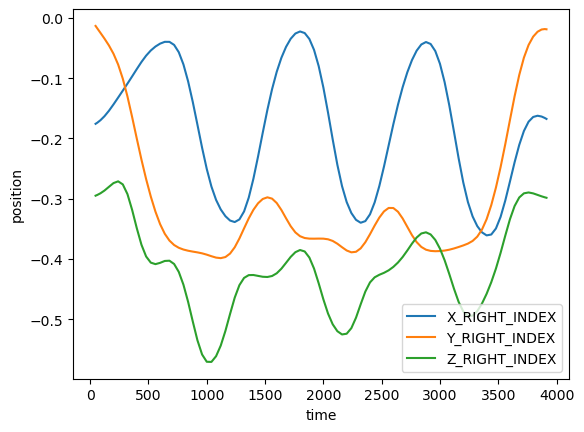

In [9]:
#load in data
gesture = 'TO-SWIM'
MT = pd.read_csv(ORTEGA_TS_DIR+gesture+"_silentgesture.csv")
MT = MT.apply(lambda x: gaussian_filter1d(x, sigma = 2)) #smooth a little
#plot X_RIGHT_INDEX and Y_RIGHT_INDEX time series with time as x-axis
plt.plot(MT['time'], MT['X_RIGHT_INDEX'], label='X_RIGHT_INDEX')
plt.plot(MT['time'], MT['Y_RIGHT_INDEX'], label='Y_RIGHT_INDEX')
plt.plot(MT['time'], MT['Z_RIGHT_INDEX'], label='Z_RIGHT_INDEX')
plt.xlabel('time')
plt.ylabel('position')
plt.legend()
plt.show()

# show gif
Image(url="./images/"+gesture+".gif")

***

# **2️⃣** DTW

## 2.1. Introduction to DTW
### DTW basics
Dynamic time warping is a method to compare and match two sequences (often time series). It tries to match sequences by allowing for some non-linear distortions in time (or another dimension), so that sequences maximally line up, so as to determine their similarity (after some distortion). This distortation has certain limits and constraints (e.g., such that values matched are not cris-crossing in time) and the degree of time distortions are effectively visualized by a warping path shown below. After matching values in one sequence to another value in the other sequence, one can compute the difference (e.g., euclidean distance between the values) that is still left between these warped sequences. This difference, error, or hereonafter "distance", provides a measure of dissimilarity between two time series. Note dynamic time warping can also compute distances between time series that have more than 1 dimension (as exemplified below). The dynamic time warping distances are best expressed after length-normalization when time series are known to have unequal lengths (otherwise, distances would add to bigger numbers for longer time series, than shorter one's, though they might be equally similar). The length-normalization consist in dividing the distance by the length of the timeseries.

### Shape DTW
There are now various variants of DTW. We are using "shape dtw" for this example, which was developed to overcome certain issues with 'classic DTW' having to do with matching segments between timeseries that should not be matched as they are actually quite dissimilar. The inventors of shapeDTW state "Shape-DTW is inherently a DTW algorithm,but additionally attempts to pair locally similar structures and to avoid matching points with distinct neighborhood structures", p. 1, for the original paper see [https://arxiv.org/pdf/1606.01601.pdf](here). For a nice introduction with how to set up your DTW pipeline, see here [https://mikolajszafraniecupds.github.io/shapedtw-python/](https://mikolajszafraniecupds.github.io/shapedtw-python/). Shape dtw operates on subsequences of the time series so that it can take into account not only a single point that needs to be matched with the another point in the sequence, but rather take into account the context of the neighboring points too. It therefore favors current point that have a similar surrounding values, rather than just single points that have matching values. We set the width of the context at 20 (i.e., 20 timesteps, context of about 800ms assuming a framerate of 25fps), as this seems to provide good matches.

### Other things to consider
There are many other different things that you need to consider when doing dynamic time warping. For example, you if you care about the general shape of a gesture but not its size, then you might want to normalize (e.g., z-scale) the time series first. Or you might not care about the place in gesture space, so you center the the position coordinates first. Also consider, we now only take a few keypoints that might not capture enough of the hand shape or other features, so you can consider adding more keypoints (a the cost of computational time).

It is important to note that when including finger keypoints, performing DTW on raw coordinates increases sensitivity to similarity in location at a cost of sensitivity to other features (e.g., handshape, movement, orientation). Imagine a scenario where two speakers produced identical gestures---perfect alignment in handshape, orientation, and movement---but in difference positions. Ideally, we would get a very low DTW distance score, as only the location differs between the gestures. However, running DTW on raw coordinates return a high distance, because difference in location is not only reflected in the wrists coordinates but also in the coordinates of each finger tip. This means that, for each hand, difference in location is reflected in **6 keypoints**, giving more weights to location. This [DTW tutorial](https://github.com/ShoAkamine/dtw-tutorial) illustrates the issue and offers a solution.

Further, what if you have a gesture consisting of multiple elements, and you want to judge another gesture as similar when it has the same elements regardless of the order of the items? Then you might not want to use dynamic time warping as it will judge a time series with elements a-b-c to be completely different from a time series with elements c-b-a (a possible time series distance measure that does judge such time series to be similar is matrix profile distance or MPdist). 

There are also a range of settings that optimize dynamic time warping performance. For example, you may want to limit the distance error calculation to be based on the begin and trailing portions of the time series as these often are difficult to match, which can be a pesky issue in classic-dtw discussed in [7] (Silva et al 2016; a possible solution for this is psy-dtw). Or it might happen that the warping leads to extreme distortions in time leading to non-sensical matches (a solution for this is limiting the maximum warping constraint, using for example a Sakoe-Chiba window). What is very important when testing DTW is to assess the warping paths of your comparisons, as this may show issues with misalignments such as those related to begin and end matching. 

## 2.2. Demonstration
For demonstration, we use a dataset from [8] Ortega & Ozyurek (2016). 

This module barely scratches the surface of what is behind dynamic time warping. Here is a list of recommended resources:

- An easy-to-follow DTW tutorial: https://github.com/ShoAkamine/dtw-tutorial. 
- A more in-depth covering of DTW: https://www.audiolabs-erlangen.de/resources/MIR/FMP/C3/C3S2_DTWbasic.html, with an open access book chapter https://www.audiolabs-erlangen.de/resources/MIR/FMP/C3/C3S2_DTWbasic.html. 
- Specific implimentation of DTW used in this notebook (shape-dtw): https://mikolajszafraniecupds.github.io/shapedtw-python/.

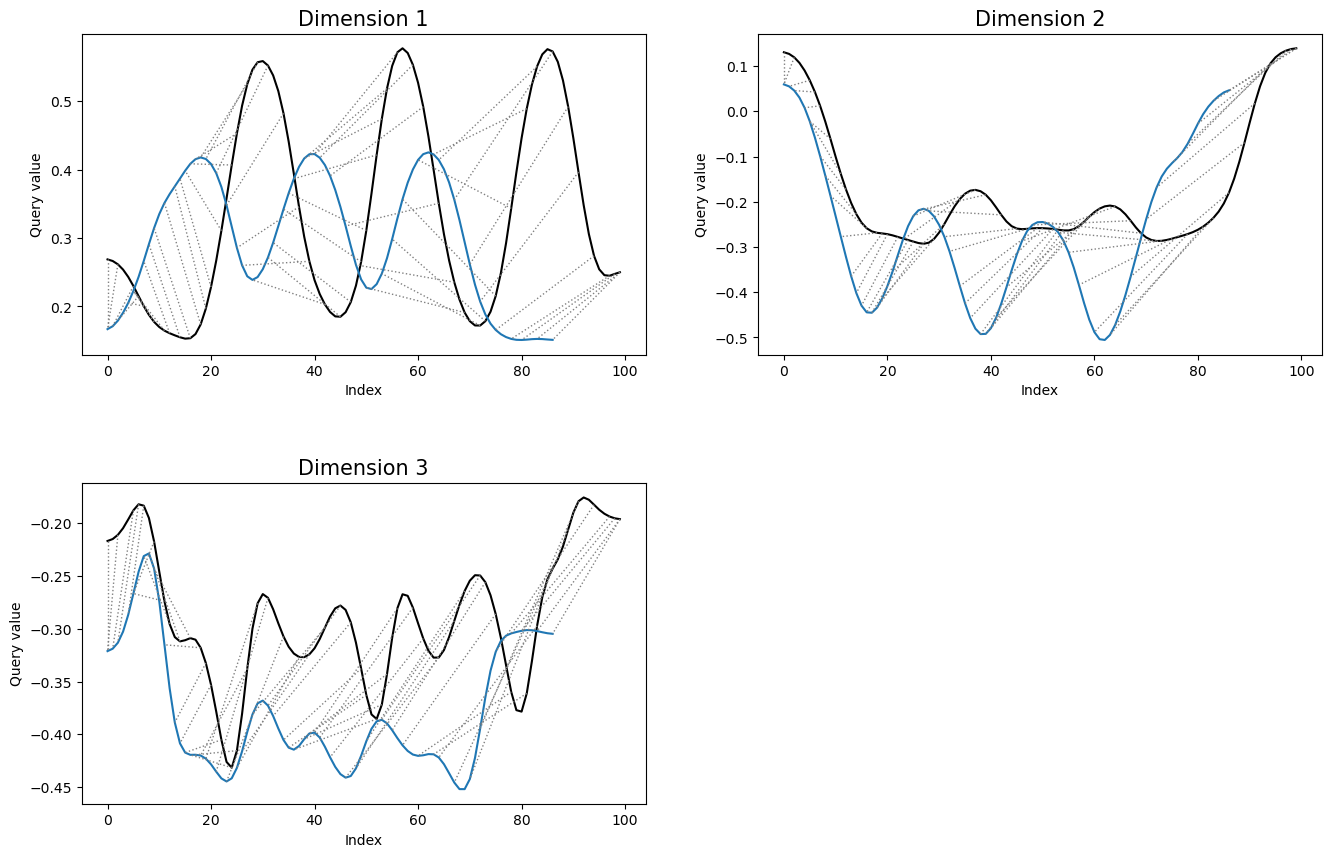

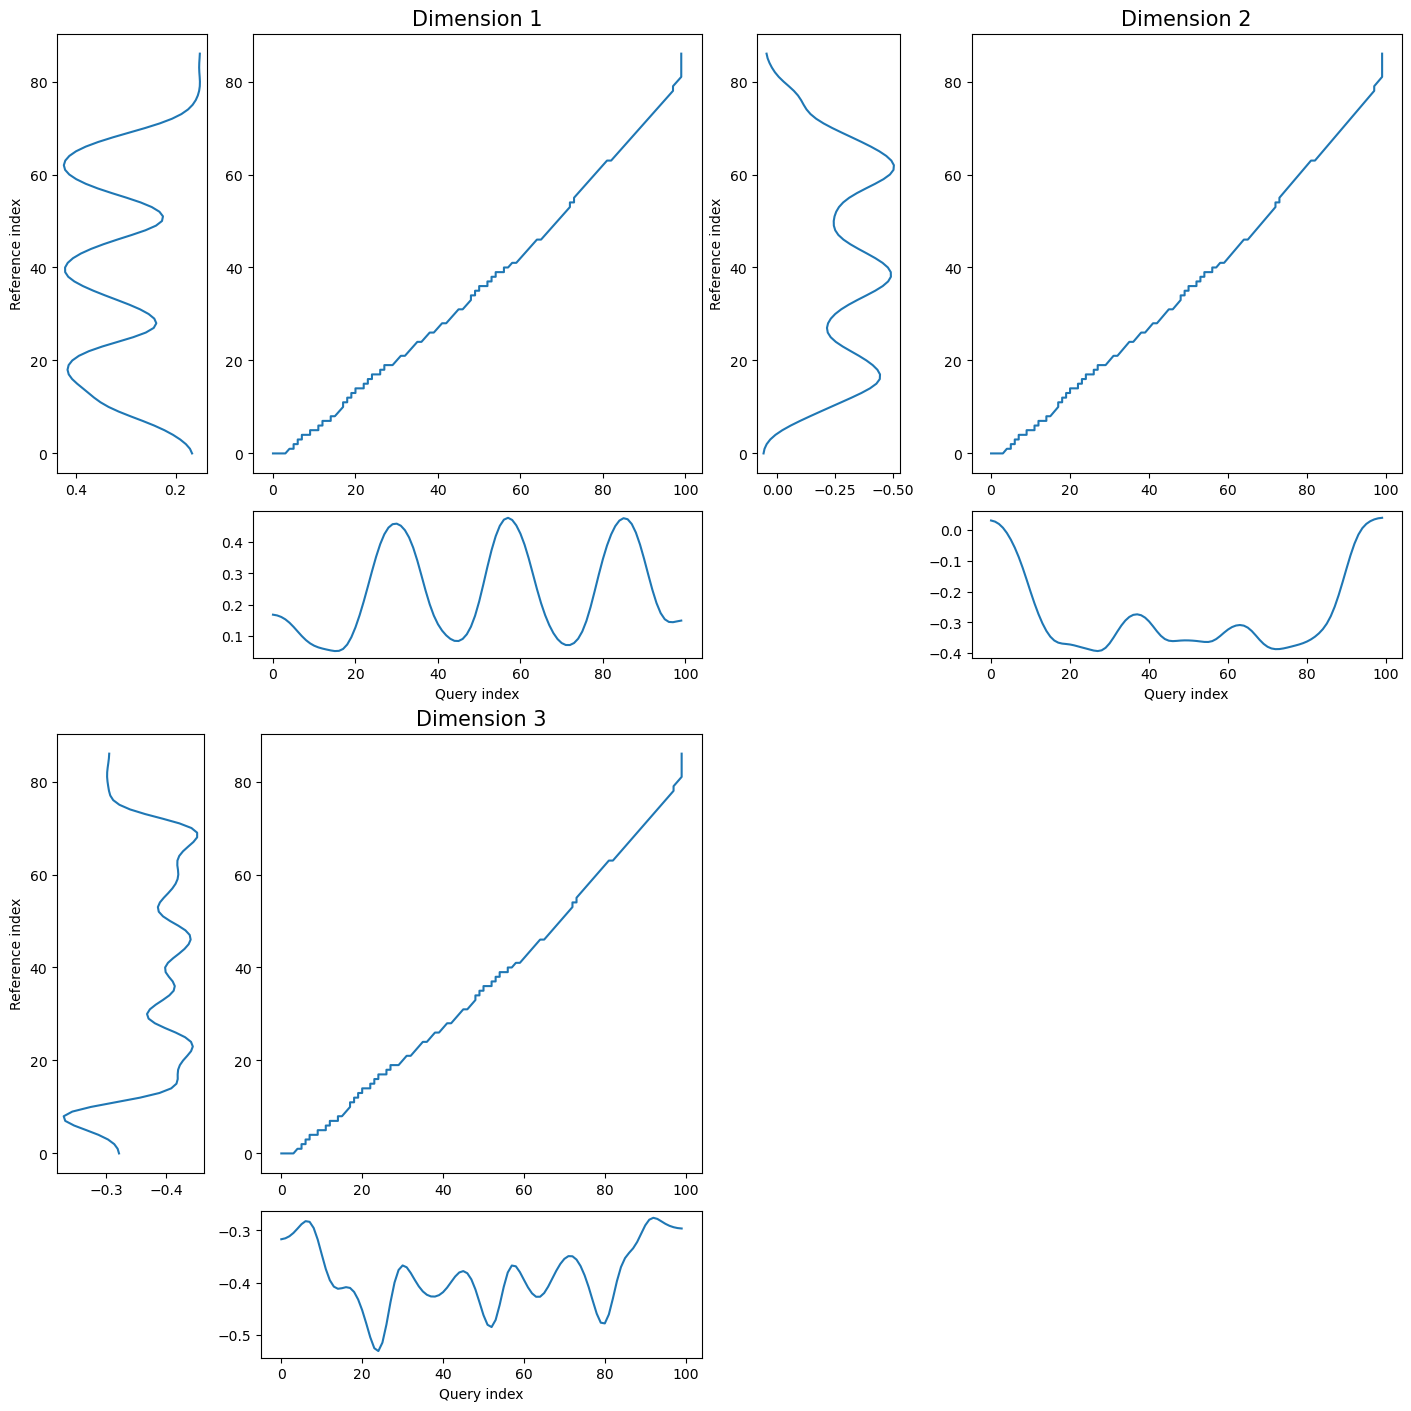

DTW distance is: 29.4
Normalized DTW distance is: 0.15720763433954837


In [10]:
# using dtw to compare distances and show a warping line
MT1 = pd.read_csv(ORTEGA_TS_DIR+"TO-SWIM_silentgesture.csv")
MT2 = pd.read_csv(ORTEGA_TS_DIR+"BUTTERFLY_silentgesture.csv") #compare example against BANANA
MT1 = MT1.apply(lambda x: gaussian_filter1d(x, sigma = 2)) #smooth a little
MT2 = MT2.apply(lambda x: gaussian_filter1d(x, sigma = 2)) #smooth a little

# select some set of features from the motion tracking dataframe
keypointindexleft = ["X_LEFT_INDEX", "Y_LEFT_INDEX", "Z_LEFT_INDEX"]
ts1 = np.array(MT1[keypointindexleft])
ts2 = np.array(MT2[keypointindexleft])

# setting up the DTW functions
shape_dtw_dependent_results = shape_dtw(
    x=ts1,
    y=ts2,
    subsequence_width=20, # so this means for the matching that we take 20 indices into account
    shape_descriptor=RawSubsequenceDescriptor(), # the local context that is taken to compare to other local context is just the raw values
    multivariate_version="dependent" 
)
dependent_distance = round(shape_dtw_dependent_results.distance, 2)
dependent_distance_normalized = shape_dtw_dependent_results.normalized_distance
dtwPlot(shape_dtw_dependent_results, plot_type="twoway", xoffset=0.1)
dtwPlot(shape_dtw_dependent_results, plot_type="threeway")

print("DTW distance is: " + str(dependent_distance))
print("Normalized DTW distance is: " + str(dependent_distance_normalized))


***

# **3️⃣** Validation

Here, we evaluate the performance of various DTW variants across two datasets. To this end, we run various types of DTW (e.g., shapeDTW, open-begin-end DTW, and DTW of your interest) and compare the distance scores against **independent human judgements**. As a stronger negative correlation between DTW distance scores and human-coded similarity ratings indicates a higher agreement between DTW and human judgement, DTW version associated with strongerst correlation has the highest predictive accuracy (for the datasets used).

## 3.1. Validation: Akamine et al. (2026) — Gesture Similarity Dataset

The first validation benchmark comes from [6] [Akamine et al. (2026)](https://doi.org/10.3758/s13428-026-02975-5), who collected **human similarity ratings** for pairs of silent gestures produced in a director–matcher task. For a subset of 400 gesture pairs (100 pairs used in the original study + 300 new pairs), trained annotators rated similarity on four independent dimensions:

| Dimension | Scale | What it captures |
|-----------|-------|-----------------|
| `location` | 0 – 5 | Where in space the gesture is made |
| `handshape` | 0 – 5 | Configuration of the fingers and palm |
| `orientation` | 0 – 5 | Rotation and facing of the hand |
| `movement` | 0 – 5 | Trajectory and dynamics of the motion |

Higher scores mean the two gestures in the pair are *more similar* on that dimension.  We sum the four scores into a single **total similarity** (0 – 20) and ask: does a lower shapeDTW kinematic distance correspond to a higher total similarity? In this validation, we use 12 keypoints: the wrist and each fingertip per hand (6 keypoints per hand).

The time series data have been preprocessed following [Akamine et al. (2026)](https://doi.org/10.3758/s13428-026-02975-5). The preprocessing steps are described in the figure below. Note that we are submitting relative finger positions to DTW instead of raw coordinates to maximize the performance. The comparison of predictive accuracy between raw and relative coordinates, and the details of relative finger positions calculation, can be found in this [DTW tutorial](https://github.com/ShoAkamine/dtw-tutorial).

<img src="Images/dtw_pipeline_akamine.png" height=400 />


### Define (custom) functions
First, we will define functions that computes DTW distances and export the results as a CSV file. Some of the DTW functions have already been defined in the `functions.py` file. Here, you can add your custom DTW distance function(s) if needed. The relavant 4 parts of the code that need to be modified are marked below.

In [11]:
#>>>>>>>>> 1. Add your custom DTW distance function here (or in functions.py) if needed <<<<<<<<<
# def my_dtw_distance(ts1, ts2, landmarks):
#     """
#     Compute the DTW distance between two time series ts1 and ts2, using the specified columns.
#     This function computes the dependent DTW distance per keypoint (X, Y) and returns the mean distance across all keypoints.
#     """        
#     distances = []
#     for name, idxs in landmarks.items():
#         if "x" not in idxs or "y" not in idxs:
#             continue
#         ts1_sliced = ts1[:, [idxs["x"], idxs["y"]]]
#         ts2_sliced = ts2[:, [idxs["x"], idxs["y"]]]
#         window_size = calculate_window_size(ts1_sliced, ts2_sliced, window_size=20)

#         res = dtw(
#             ts1_sliced, ts2_sliced,
#             step_pattern="asymmetric",
#             open_begin=True, open_end=True,
#             window_type="sakoechiba", window_args={"window_size": window_size},
#             )
#         distances.append(res.normalized_distance)

#     return float(np.mean(distances))


def compute_dtw(ts1, ts2, cols, hand):
    """
    Compute both DTW and shapeDTW distances between two time series ts1 and ts2.
    Returns a dictionary with 'dtw' and 'shape_dtw' distances.
    """

    # Mirror ts2 for comparison
    ts2_mirror = mirror_ts(ts2, cols)

    # Get landmarks for left and right hands (DTW will be computed separately for landmarks of each hand)
    left_landmarks, right_landmarks = get_landmarks(cols)

    # Compute DTW distances for each hand
    obe_dtw_dist_left           = obe_dtw_distance(ts1, ts2, left_landmarks)
    obe_dtw_dist_right          = obe_dtw_distance(ts1, ts2, right_landmarks)
    mean_obe_dtw_dist           = (obe_dtw_dist_left + obe_dtw_dist_right) / 2
    obe_dtw_dist_left_mirror    = obe_dtw_distance(ts1, ts2_mirror, left_landmarks)
    obe_dtw_dist_right_mirror   = obe_dtw_distance(ts1, ts2_mirror, right_landmarks)
    mean_obe_dtw_dist_mirror    = (obe_dtw_dist_left_mirror + obe_dtw_dist_right_mirror) / 2

    # Compute shapeDTW distances for each hand
    shape_dtw_dist_left         = shape_dtw_distance(ts1, ts2, left_landmarks)
    shape_dtw_dist_right        = shape_dtw_distance(ts1, ts2, right_landmarks)
    mean_shape_dtw_dist         = (shape_dtw_dist_left + shape_dtw_dist_right) / 2
    shape_dtw_dist_left_mirror  = shape_dtw_distance(ts1, ts2_mirror, left_landmarks)
    shape_dtw_dist_right_mirror = shape_dtw_distance(ts1, ts2_mirror, right_landmarks)
    mean_shape_dtw_dist_mirror  = (shape_dtw_dist_left_mirror + shape_dtw_dist_right_mirror) / 2

    #>>>>>>>>> 2. Add any additional distance computations here if needed <<<<<<<<<
    # my_dtw_dist = my_dtw_distance(ts1, ts2, landmarks)
    # my_dtw_dist_mirror = my_dtw_distance(ts1, ts2_mirror, landmarks)
    # mean_my_dtw_dist = (my_dtw_dist + my_dtw_dist_mirror) / 2


    # Select the appropriate distances based on the specified hand
    obe_dtw_dist = select_distance(obe_dtw_dist_left, obe_dtw_dist_right, mean_obe_dtw_dist,
                                obe_dtw_dist_left_mirror, obe_dtw_dist_right_mirror, mean_obe_dtw_dist_mirror,
                                hand)
    shape_dtw_dist = select_distance(shape_dtw_dist_left, shape_dtw_dist_right, mean_shape_dtw_dist,
                                shape_dtw_dist_left_mirror, shape_dtw_dist_right_mirror, mean_shape_dtw_dist_mirror,
                                hand)
    
    #>>>>>>>>> 3. Add any additional distance selection here if needed <<<<<<<<<
    # my_dtw_dist = select_distance(my_dtw_dist_left, my_dtw_dist_right, mean_my_dtw_dist,
    #                               my_dtw_dist_left_mirror, my_dtw_dist_right_mirror, mean_my_dtw_dist_mirror,
    #                               hand)
    
    # check if the distances are based on mirrored time series
    mirrored_distances = [obe_dtw_dist_left_mirror, obe_dtw_dist_right_mirror, mean_obe_dtw_dist_mirror]
    mirrored = True if obe_dtw_dist in mirrored_distances else False

    #>>>>>>>>> 4. Add any additional distance outputs here if needed <<<<<<<<<
    return {
        "obe_dtw": obe_dtw_dist,
        "shape_dtw": shape_dtw_dist,
        "mirrored": mirrored,
        # "my_dtw": my_dtw_dist
    }

### Compute DTW
Here, we compute dependent DTW distance per landmark (e.g., x_left_wrist) and then take the average.

In [12]:
# Load annotation and build total similarity score (higher = more similar)
ak = pd.read_csv(AKAMINE_DIR + "gesture_annotation.csv")
ak_sim = ak[ak["location"].notna()].copy()
ak_sim["total_sim"] = ak_sim[["location", "handshape", "orientation", "movement"]].sum(axis=1)

# Compute shapeDTW for every sim-coded pair (reuses KP / load_ts / my_timeseries_distance from above)
ak_results = []
for _, row in tqdm(ak_sim.iterrows(), total=len(ak_sim), desc="Comuting DTW distance for Akamine dataset"):
    cid     = int(row["comparison_id"])
    path_a  = AKAMINE_TS_DIR + f"{cid}_1.csv" # ts for speaker A
    path_b  = AKAMINE_TS_DIR + f"{cid}_2.csv" # ts for speaker B
    df_ts_a = pd.read_csv(path_a)
    df_ts_b = pd.read_csv(path_b)
    cols    = [c for c in df_ts_a.columns if c.startswith("x_") or c.startswith("y_")]
    hand    = row["hands_dtw"] # "left" if both speakers used left hand, "right" if both used right hand, "left_right" if A used left and B used right, etc

    # convert dataframes to numpy arrays for DTW computation
    # note that if the df contain columns that are not numeric, slicing it returns an object dtype, which is not compatible with dtw. 
    # therefore, we select only the numeric columns for the dtw computation.
    ts_a = df_ts_a[cols].values
    ts_b = df_ts_b[cols].values
    
    try:
        results = compute_dtw(ts_a, ts_b, cols, hand)
        results.update({"comparison_id": cid,
                        "total_sim": row["total_sim"],
                        "hands_dtw": hand})
        ak_results.append(results)
    except Exception as e:
        print(f"pair {cid}: {e}")
        continue

ak_df = pd.DataFrame(ak_results).dropna()
# rearrange columns for clarity
ak_df = ak_df[["comparison_id", "total_sim", "hands_dtw", "mirrored", 
                "obe_dtw", "shape_dtw"]]
print(f"Pairs computed: {len(ak_df)}")

Comuting DTW distance for Akamine dataset: 100%|██████████| 400/400 [00:12<00:00, 30.93it/s]

Pairs computed: 400


### Check performances of DTW variants

In [13]:
# add `average distance` column
df_akamine = pd.read_csv(AKAMINE_DIR + "dtw_distance_zoom_mirrored.csv")

# left_join the two dataframes on the index (comparison_id)
ak_df = ak_df.reset_index(drop=True)
ak_df = ak_df.merge(df_akamine[['comparison_id', 'average_distance']], on='comparison_id', how='left')

shapeDTW (current)              Pearson r=-0.445 (p=0.000)  Spearman rho=-0.449  slope=-0.3352
open-begin-end DTW              Pearson r=-0.441 (p=0.000)  Spearman rho=-0.452  slope=-0.3387
Akamine et al. (2026)           Pearson r=-0.422 (p=0.000)  Spearman rho=-0.446  slope=-0.2756


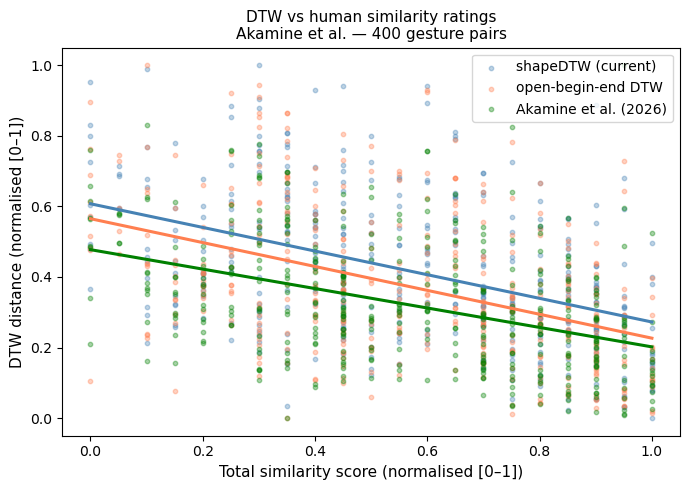

In [14]:
# >>>>>>>>>> Add any additional distance columns here if needed <<<<<<<<<
dtws = ["shape_dtw", "obe_dtw", "average_distance"] # add "my_dtw" if you implemented a custom DTW distance function
labels = ["shapeDTW (current)", "open-begin-end DTW", "Akamine et al. (2026)"] # add label for "my_dtw" if needed
colors = ["steelblue", "coral", "green"] # add color for "my_dtw" if needed
plot_info_list = list(zip(dtws, labels, colors))


# plot the scatter plots and regression lines for each DTW method
fig, ax = plt.subplots(figsize=(7, 5))

x_raw = ak_df["total_sim"]
x_norm = minmax(x_raw)

for col, label, color in plot_info_list:
    y_norm = minmax(ak_df[col])
    
    ax.scatter(x_norm, y_norm, alpha=0.35, s=10, color=color, label=label)
    m, b  = np.polyfit(x_norm, y_norm, 1)
    xline = np.linspace(x_norm.min(), x_norm.max(), 200)
    ax.plot(xline, m * xline + b, color=color, linewidth=2.2)
    r_p, p_p = pearsonr(x_norm, y_norm)
    r_s, _   = spearmanr(x_norm, y_norm)
    print(f"{label:30s}  Pearson r={r_p:.3f} (p={p_p:.3f})  Spearman rho={r_s:.3f}  slope={m:.4f}")

ax.set_xlabel("Total similarity score (normalised [0–1])", fontsize=11)
ax.set_ylabel("DTW distance (normalised [0–1])", fontsize=11)
ax.set_title("DTW vs human similarity ratings\nAkamine et al. — 400 gesture pairs", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

*******

## 3.2. Validation: Motamedi et al. (2021) — Gesture Evolution Dataset
Next, we will validate DTW on the dataset by [9] [Motamedi and colleages (2019)](https://www.sciencedirect.com/science/article/abs/pii/S0010027719301234). This dataset is suitable for validation: it documents how silent gestures for the same concepts evolve across 5 transmission chains and 5 generations of participants, annotated at the symbol level using a formal gesture coding scheme.

**The annotation: `code_string`**

Each gesture is described by a `code_string` — a comma-separated sequence of movement components, e.g.:

```
1hKnock<right>, 1hBadge<right>, 2hFists.wristsX
```

This encodes *what* is done (knocking, showing a badge, crossing wrists) in sequence. Two gestures that share many components should look kinematically similar too — this is the hypothesis we test.

We compute two symbolic distance metrics from the code strings:
- **Token-level Levenshtein distance** — how many insertions / deletions / substitutions of gesture components separate the two strings
- **Token-level Jaccard distance** — `1 − |shared components| / |all components|`

We then ask: **do pairs with lower symbolic distance also show lower shapeDTW kinematic distance?** We will restrict our comparisons between gestures that portray the convey target.

In [15]:
# Display the GIF inline (IPython.display.Image imported in the first code cell)
Image(url="./images/arrest_evolution_ch1.gif")

### Compute DTW
As in the previous validation, we do dependent DTW on each x, y keypoint, and then add them up (which makes it an independent DTW with dependent DTW distance per 2D keypoint timeseries).

Set `OVERWRITE` to `True` if you want to recompute these. This takes some time to run. 

In [16]:
OVERWRITE = False
# Load processed data
df = pd.read_csv(MOTAMEDI_PROC_DIR + "ex1_processed.csv")
all_pairs = pd.read_csv(MOTAMEDI_PROC_DIR + "ex1_all_pairs.csv").to_numpy()
with open(MOTAMEDI_PROC_DIR + "ex1_cols_cache.pkl", "rb") as f:
    cols_cache = pickle.load(f)

# Load precomputed annotation distance matrices
lev_mat  = pd.read_csv(MOTAMEDI_PROC_DIR + "ex1_levenshtein.csv", index_col=0)
jacc_mat = pd.read_csv(MOTAMEDI_PROC_DIR + "ex1_jaccard.csv",     index_col=0)


# Select a subset of pairs to evaluate
N_COMPARISONS = 10000 # set to None to evaluate all pairs
RANDOM_SEED   = 40
OVERWRITE     = False # set to True to recompute the distances instead of loading them

if N_COMPARISONS is not None and N_COMPARISONS < len(all_pairs):
    rng      = np.random.default_rng(RANDOM_SEED)
    selected = [all_pairs[k]
                for k in rng.choice(len(all_pairs), N_COMPARISONS, replace=False)]
else:
    selected = all_pairs

print(f"Total same-target pairs  : {len(all_pairs)}")
print(f"Pairs to evaluate        : {len(selected)}")

# cache path is keyed on the subset so a different N/seed does not reuse an old file
tag      = f"n{len(selected)}_seed{RANDOM_SEED}"
res_path = MOTAMEDI_PROC_DIR + f"ex1_dtw_results_{tag}.csv"


# Compute shapeDTW distances for selected pairs (or load them back in)
if OVERWRITE or not os.path.exists(res_path):
    results = []
    for i, j in tqdm(selected, desc="shapeDTW"):
        ri, rj = df.iloc[i], df.iloc[j]

        # load from cache and apply global normalisation
        cols_i      = cols_cache[ri.filepath]
        cols_j      = cols_cache[rj.filepath]
        landmarks_i = get_landmarks_motamedi(cols_i)
        ts_i        = normalise_ts(load_ts(ri.filepath))
        ts_j        = normalise_ts(load_ts(rj.filepath))
        ts_j_mirror = mirror_ts(ts_j, cols_j)

        try:
            # obe DTW
            obe_dtw_dist        = obe_dtw_distance(ts_i, ts_j, landmarks_i)
            obe_dtw_dist_mirror = obe_dtw_distance(ts_i, ts_j_mirror, landmarks_i)
            obe_dtw_best        = min(obe_dtw_dist, obe_dtw_dist_mirror)
            # shapeDTW
            shape_dtw_dist          = shape_dtw_distance(ts_i, ts_j, landmarks_i)
            shape_dtw_dist_mirror   = shape_dtw_distance(ts_i, ts_j_mirror, landmarks_i)
            shape_dtw_best          = min(shape_dtw_dist, shape_dtw_dist_mirror)
            #>>>>> 1. Add any additional distance metrics here if needed <<<
            # my_dtw_dist          = my_dtw_distance(ts_i, ts_j, landmarks_i)
            # my_dtw_dist_mirror   = my_dtw_distance(ts_i, ts_j_mirror, landmarks_i)
            # my_dtw_best          = min(my_dtw_dist, my_dtw_dist_mirror)
        except Exception:
            continue
        #>>>>>>>>> 2. Add any additional distance outputs here if needed <<<<<<<
        results.append({
            "gesture_id_i": ri.gesture_id,
            "gesture_id_j": rj.gesture_id,
            "levenshtein": float(lev_mat.loc[ri.gesture_id, rj.gesture_id]),
            "jaccard":     float(jacc_mat.loc[ri.gesture_id, rj.gesture_id]),
            "obe_dtw":     obe_dtw_best,
            "shape_dtw":   shape_dtw_best,
            # "my_dtw":       my_dtw_best,  # Example for additional metric
        })

    df_res = pd.DataFrame(results).dropna()
    df_res.to_csv(res_path, index=False)
    print(f"Computed and saved: {len(df_res)} pairs -> {res_path}")
else:
    df_res = pd.read_csv(res_path)
    print(f"Loaded {len(df_res)} pairs from {res_path} (set OVERWRITE = True to recompute)")

Total same-target pairs  : 20937
Pairs to evaluate        : 10000


shapeDTW: 100%|██████████| 10000/10000 [33:53<00:00,  4.92it/s] 

Completed: 9933 pairs


### Check performances of DTW variants


**Levenshtein (norm.)**
shapeDTW (current)              Pearson r=0.014 (p=1.57e-01)  Spearman rho=0.014
open-begin-end DTW              Pearson r=-0.025 (p=1.35e-02)  Spearman rho=-0.030

**Jaccard**
shapeDTW (current)              Pearson r=0.269 (p=6.40e-158)  Spearman rho=0.300
open-begin-end DTW              Pearson r=0.236 (p=4.41e-121)  Spearman rho=0.272


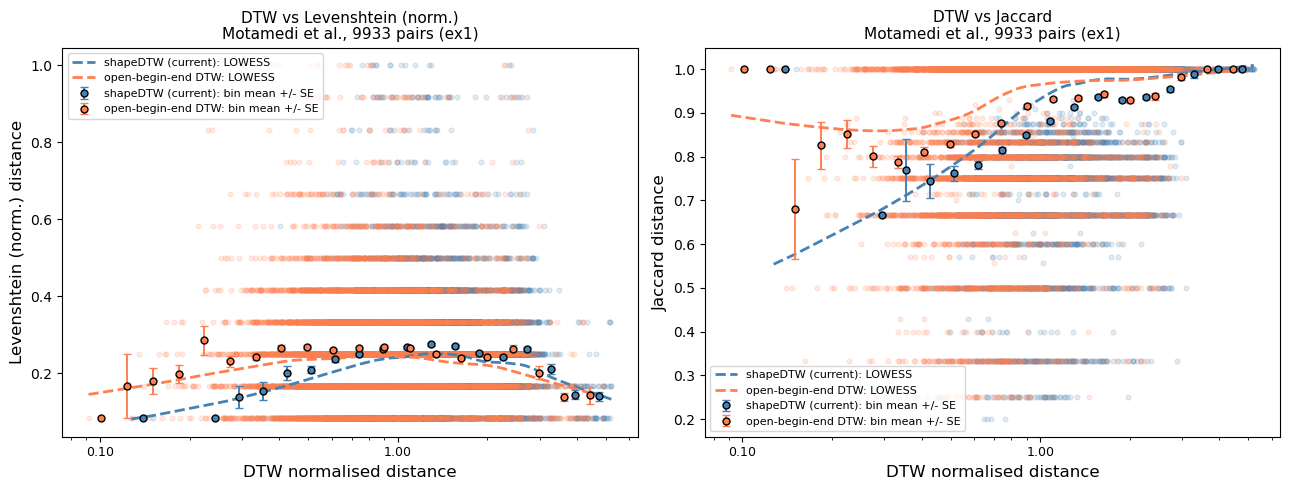

In [22]:
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from matplotlib.ticker import LogLocator, ScalarFormatter

# >>>>>>>>>> Add any additional distance columns here if needed <<<<<<<
dtws   = ["shape_dtw", "obe_dtw"]
labels = ["shapeDTW (current)", "open-begin-end DTW"]
colors = ["steelblue", "coral"]
plot_info_list = list(zip(dtws, labels, colors))

df_res["lev_norm"] = df_res["levenshtein"] / df_res["levenshtein"].max()
sim_info = [("lev_norm", "Levenshtein (norm.)"), ("jaccard", "Jaccard")]

N_BINS = 20

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (sim_col, sim_label) in zip(axes, sim_info):
    print(f"\n**{sim_label}**")

    for dtw_col, dtw_label, color in plot_info_list:
        valid = df_res[[dtw_col, sim_col]].dropna().copy()
        valid = valid[(valid[sim_col] > 0) & (valid[dtw_col] > 0)]

        # - raw scatter
        ax.scatter(valid[dtw_col], valid[sim_col],
                   alpha=0.15, s=12, color=color, label="_nolegend_")

        # - binned means +/- SE (bins in log space)
        valid["bin"] = pd.cut(np.log10(valid[dtw_col]), bins=N_BINS)
        bin_stats = valid.groupby("bin", observed=True)[sim_col].agg(["mean", "std", "count"])
        bin_stats["se"] = bin_stats["std"] / np.sqrt(bin_stats["count"])
        bin_centers = 10 ** np.array(bin_stats.index.map(lambda b: float(b.mid)), dtype=float)
        ax.errorbar(bin_centers, bin_stats["mean"], yerr=bin_stats["se"],
                    fmt="o", color=color, markeredgecolor="black", markersize=5,
                    linewidth=1.4, capsize=3, label=f"{dtw_label}: bin mean +/- SE", zorder=5)

        # - LOWESS (fitted in log space, plotted on log axes)
        lowess = sm.nonparametric.lowess(
            np.log10(valid[sim_col]), np.log10(valid[dtw_col]), frac=0.3)
        ax.plot(10 ** lowess[:, 0].astype(float), 10 ** lowess[:, 1].astype(float),
                color=color, linewidth=2, linestyle="--", label=f"{dtw_label}: LOWESS")

        # - stats on log-transformed values
        r_p, p_p = pearsonr(np.log10(valid[dtw_col]), np.log10(valid[sim_col]))
        r_s, _   = spearmanr(valid[dtw_col], valid[sim_col])
        print(f"{dtw_label:30s}  Pearson r={r_p:.3f} (p={p_p:.2e})  Spearman rho={r_s:.3f}")

    # - log x-axis with reliable tick labels
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.get_major_formatter().set_scientific(False)
    ax.tick_params(axis="x", which="both", labelsize=9)

    ax.set_xlabel("DTW normalised distance", fontsize=12)
    ax.set_ylabel(f"{sim_label} distance", fontsize=12)
    ax.set_title(f'DTW vs {sim_label}\nMotamedi et al., {len(df_res)} pairs (ex1)',
                 fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

So it is clear that in regions where we have the most datapoints we also see a clear positive correlation, which means that distances between human coded gesture strings correlates with the kinematic distances.

# **4️⃣** Supplementary

### Check if the mirroring works properly
Here, we will check if the mirroring algorithm mirrors the time series data properly. To this end, we will compare two time series: (i) ts data generated from mirrored videos and (ii) ts data generated from original video but mirrored post-hoc using the `mirror_ts()` function. If the mirroring works properly, these data will look similar. If they do not resemble, `mirror_ts()` function needs to be revised.

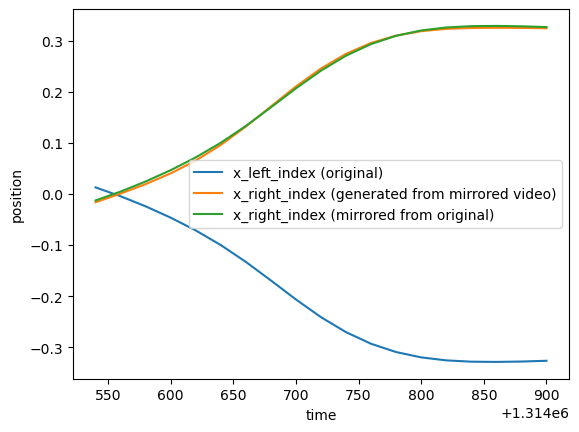

In [18]:
test_dir = "../data/ValidationDataAkamine/test/"

# Load the mirrored time series generated from the mirrored video
mirrored_ts_1 = pd.read_csv(test_dir + "758_2_mirrored.csv")

# Load the original time series and mirror it using the mirror_ts function
original_ts = pd.read_csv(test_dir + "758_2.csv")
cols = [c for c in original_ts.columns if c.startswith("x_") or c.startswith("y_")]
original_ts_values = original_ts[cols].values
mirrored_ts_2 = mirror_ts(original_ts_values, cols)
mirrored_ts_2 = pd.DataFrame(mirrored_ts_2, columns=cols)

# Visualize the mirrored time series
plt.plot(original_ts['time'], original_ts['x_left_index_finger_tip_relative'], label='x_left_index (original)')
plt.plot(mirrored_ts_1['time'], mirrored_ts_1['x_right_index_finger_tip_relative'], label='x_right_index (generated from mirrored video)')
plt.plot(mirrored_ts_1['time'], mirrored_ts_2['x_right_index_finger_tip_relative'], label='x_right_index (mirrored from original)')
plt.xlabel('time')
plt.ylabel('position')
plt.legend()
plt.show()

The plot shows that `mirror_ts()` function generates time series data that resemble the data generated from mirrored videos, indicating that the mirroring algorithm is working as expected.

# References

1. Pouw, W. , & Dixon, J. A. (2020). Gesture networks: Introducing dynamic time warping and network analysis for the kinematic study of gesture ensembles. Disccurrente Processes, 57(4), 301-319. doi: https://doi.org/10.1080/0163853X.2019.1678967

2. Pouw, W. , Dingemanse, M., Motamedi, Y., Özyürek, A. (2021). A systematic investigation of gesture kinematics in evolving manual languages in the lab. Cognitive Science. doi (open access): https://doi.org/10.1111/cogs.13014

3. Pouw, W., de Wit, J., Bögels, S., Rasenberg, M., Milivojevic, B., & Özyürek, A. (2021). Semantically related gestures move alike: Towards a distributional semantics of gesture kinematics. In V. G. Duffy (Ed.), Digital Human Modeling and Applications in Health, Safety, Ergonomics and Risk Management. Human Body, Motion and Behavior (pp. 269–287). Springer International Publishing. https://doi.org/10.1007/978-3-030-77817-0_20

4. Trujillo, J. P., Dideriksen, C., Tylén, K., Christiansen, M. H., & Fusaroli, R. (2023). The dynamic interplay of kinetic and linguistic coordination in Danish and Norwegian conversation. Cognitive Science, 47(6), e13298. https://doi.org/10.1111/cogs.13298

5. Akamine, S., Meyer, A. S., & Ozyurek, A. (2026). Lexical alignment and speaker visibility influence gestural alignment in conversation: Implications for theories of linguistic alignment (Kjhd2_v1). PsyArXiv. https://osf.io/preprints/psyarxiv/kjhd2_v1/

6. Akamine, S., Dingemanse, M., & Özyürek, A. (2026). Validating dynamic time warping as a measure of gesture form similarity. Behavior Research Methods, 58(4), 110. https://doi.org/10.3758/s13428-026-02975-5

7. Silva, D. F., Batista, G. A. E. P. A., & Keogh, E. (2016). On the effect of endpoints on dynamic time warping. SIGKDD Workshop on Mining and Learning from Time Series, II. San Francisco, USA.

8. Ortega, G., & Özyürek, A. (2020). Systematic mappings between semantic categories and types of iconic representations in the manual modality: A normed database of silent gesture. Behavior Research Methods, 52(1), 51-67.

9. Motamedi, Y., Schouwstra, M., Smith, K., Culbertson, J., & Kirby, S. (2019). Evolving artificial sign languages in the lab: From improvised gesture to systematic sign. Cognition, 192, 103964. https://doi.org/10.1016/j.cognition.2019.05.001

10. Cliff, O. M., Bryant, A. G., Lizier, J. T., Tsuchiya, N., & Fulcher, B. D. (2023). Unifying pairwise interactions in complex dynamics. Nature Computational Science, 3(10), 883-893. https://doi.org/10.1038/s43588-023-00519-x

11. Pearson, L., Nuttall, T., & Pouw, W. (2025). The Co‐Structuring of Gesture‐Vocal Dynamics: An Exploration in Karnatak Music Performance. Cognitive Science, 49(11), e70137.  https://doi.org/10.1111/cogs.70137